In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd

In [21]:
SMALL_SIZE = 18
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 


lts = ['-', '--', '-.',':', '-']


steps = ['0.1', '0.7']

idx = [0, 1]

names = ['CLs.npy',
'CNs.npy',
'CTs.npy',
'YLs.npy',
'YNs.npy',
'YTs.npy',
'mLs.npy',
'mNs.npy',
'mTs.npy']

def mean_dist_true(m_true, Y):
    d, n = Y.shape
    running_mean = Y[:, 0]
    conv = np.zeros(n)
    conv[0] = np.power(np.linalg.norm(running_mean - m_true), 2)
    for i in range(n-1):
        running_mean = (i+1) * running_mean / (i+2) + (1) * Y[:, i] / (i+2)
        conv[i+1] = np.power(np.linalg.norm(running_mean - m_true), 2)
    return conv

def cov_dist_true(C_true, Y):
    d, n = Y.shape
    running_cov = np.outer(Y[:, 0], Y[:, 0])
    conv = np.zeros(n)
    conv[0] = np.power(np.linalg.norm(running_cov - C_true), 2) / np.power(np.linalg.norm(Sigma), 2)
    for i in range(n-1):
        running_cov = (i+1) * running_cov / (i+2) + (1) * np.outer(Y[:, i], Y[:, i]) / (i+2)
        conv[i+1] = np.power(np.linalg.norm(running_cov - C_true), 2)/ np.power(np.linalg.norm(Sigma), 2)
    return conv

sm = 10

In [22]:
YNs = np.load('Gaussian_' + steps[0] + '/' + 'YNs.npy')

d, N, reps = YNs.shape
N2 = sm * N
convL = np.zeros((sm * N, len(steps)))
convN = np.zeros((N, len(steps)))
convT = np.zeros((sm * N, len(steps)))
i=0

for s in steps:
    YNs = np.load('Gaussian_' + s + '/' + 'YNs.npy')
    YLs = np.load('Gaussian_' + s + '/' + 'YLs.npy')
    YTs = np.load('Gaussian_' + s + '/' + 'YTs.npy')
    
    for r in range(reps):
        print(r)
        convN[:, i] += mean_dist_true(np.zeros((d,)), YNs[:,:,r]) / reps
        convL[:, i] += mean_dist_true(np.zeros((d,)), YLs[:,:,r]) / reps
        convT[:, i] += mean_dist_true(np.zeros((d,)), YTs[:,:,r]) / reps
    
    i += 1
    
np.save('plot_data/convN_mean.npy', convN)
np.save('plot_data/convL_mean.npy', convL)
np.save('plot_data/convT_mean.npy', convT)    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


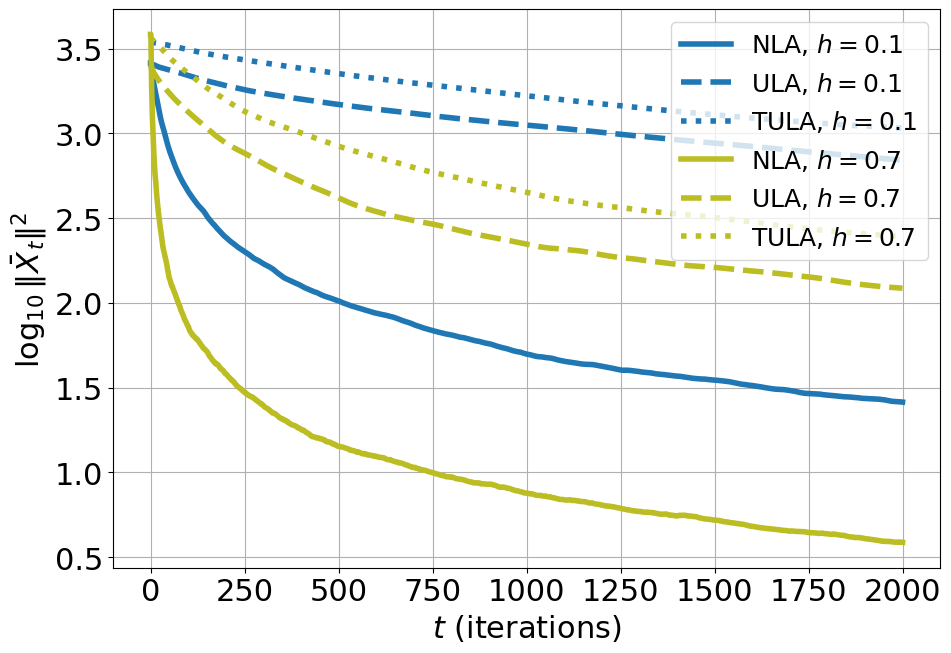

In [23]:
convN = np.load('plot_data/convN_mean.npy')
convL = np.load('plot_data/convL_mean.npy')
convT = np.load('plot_data/convT_mean.npy')

p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue', "tab:olive", "tab:purple", "tab:orange"]

for i in idx:
    s = steps[i]
    ax.plot(np.log10(convN[0:N,i]), color = colors[i], linestyle = lts[0], label = r'NLA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convL[0:N,i]), color = colors[i], linestyle = lts[1], label = r'ULA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convT[0:N,i]), color = colors[i], linestyle = lts[3], label = r'TULA, $h=$' + s, linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend(loc = 'upper right')
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\log_{10} \|\bar X_t\|^2$')   
ax.grid()
plt.tight_layout()

plt.savefig('plots/mvg_mean_iters_legend.pdf')

In [24]:
YNs = np.load('Gaussian_' + s + '/' + 'YNs.npy')

d, N, reps = YNs.shape
N2 = sm * N
convL = np.zeros((sm * N, len(steps)))
convN = np.zeros((N, len(steps)))
convT = np.zeros((sm * N, len(steps)))


for i in idx:
    s = steps[i]
    YNs = np.load('Gaussian_' +s + '/' + 'YNs.npy')
    YLs = np.load('Gaussian_' +s + '/' + 'YLs.npy')
    YTs = np.load('Gaussian_' +s + '/' + 'YTs.npy')
    Sigma = np.load('Gaussian_' +s + '/' + 'Sigma.npy')

    
    for r in range(reps):
        print(r)
        convN[:, i] += cov_dist_true(Sigma, YNs[:,:,r]) / reps
        convL[:, i] += cov_dist_true(Sigma, YLs[:,:,r]) / reps
        convT[:, i] += cov_dist_true(Sigma, YTs[:,:,r]) / reps
    
    i += 1
    
np.save('plot_data/convN_scat.npy', convN)
np.save('plot_data/convL_scat.npy', convL)
np.save('plot_data/convT_scat.npy', convT)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


ValueError: keyword grid_b is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_caps

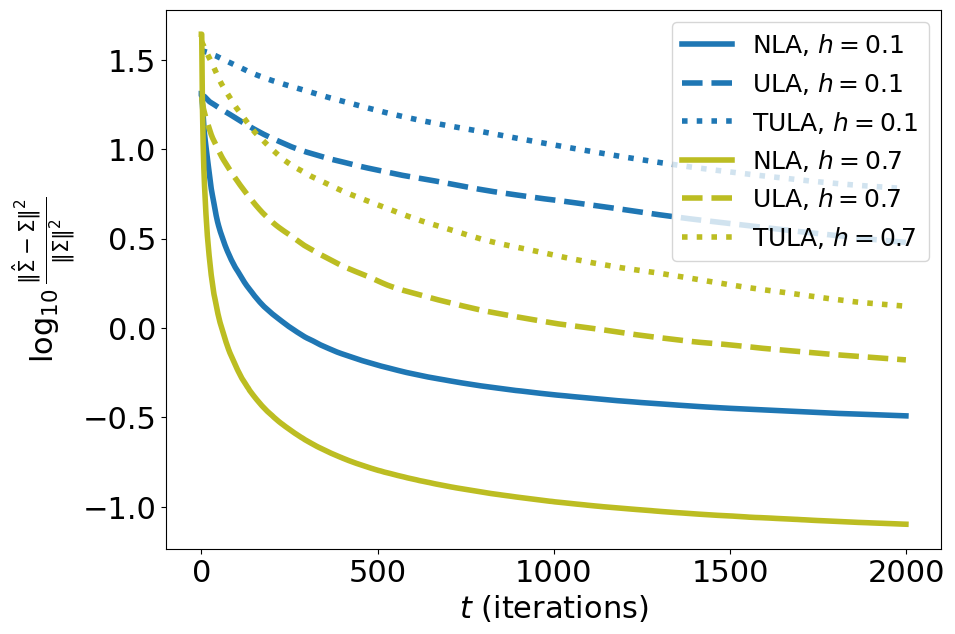

In [25]:
convN = np.load('plot_data/convN_scat.npy')
convL = np.load('plot_data/convL_scat.npy')
convT = np.load('plot_data/convT_scat.npy')

p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue', "tab:olive", "tab:purple", "tab:orange"]
for i in idx:
    s = steps[i]
    ax.plot(np.log10(convN[0:N,i]), color = colors[i], linestyle = lts[0], label = r'NLA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convL[0:N,i]), color = colors[i], linestyle = lts[1], label = r'ULA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convT[0:N,i]), color = colors[i], linestyle = lts[3], label = r'TULA, $h=$' + s, linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend(loc = 'upper right')
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\log_{10} \frac{\|\hat \Sigma - \Sigma\|^2}{\| \Sigma \|^2}$')   
ax.grid(b = True)
plt.tight_layout()

plt.savefig('plots/mvg_cov_iters_legend.pdf')

In [ ]:
p, ax = plt.subplots(figsize = (10, 7))

colors = ['tab:blue', "tab:olive", "tab:purple", "tab:orange"]
i = 0
idx = [0]
for i in idx:
    s = steps[i]
    ax.plot(np.log10(convN[0:N,i]), color = colors[i], linestyle = lts[0], label = r'NLA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convL[0:N,i]), color = colors[i], linestyle = lts[1], label = r'ULA, $h=$' + s, linewidth = 4)
    ax.plot(np.log10(convT[0:N,i]), color = colors[i], linestyle = lts[3], label = r'TULA, $h=$' + s, linewidth = 4)
    
    i += 1
    
handles, labels = ax.get_legend_handles_labels() 
ax.legend(loc = 'upper right')
plt.xlabel(r'$t$ (iterations)')    
plt.ylabel(r'$\log_{10} \|\bar X_t\|^2$')   
ax.grid(b = True)

plt.savefig('plots/mvg_mean_iters.pdf')

In [ ]:
import math
from scipy.linalg import sqrtm, inv

SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE) 


In [ ]:
s = '0.7'
Sigma = np.load(s + '/' + 'Sigma.npy')
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')

d, N, reps = YNs.shape
YN = YNs[:,:,0]
YL = YLs[:,:,0]
YT = YTs[:,:,0]


ts = np.linspace(0, math.pi * 2, 100)
xs = np.cos(ts)
ys = np.sin(ts)
directions = 2*np.array([xs, ys]) 

CN = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YN2 = ((CN)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))


CT = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YT2 = ((CT)).dot(directions)#+ np.outer(np.mean(YTs.reshape( d, N * reps), 1), np.ones(100))


CL = sqrtm(np.cov(YL[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YL2 = ((CL)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))

ell = sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions)

plt.figure(figsize = (6,6))

plt.plot(YL[0,1:1000],YL[-1,1:1000], 'o', color = 'tab:red', alpha = 0.8, markersize = 15,markerfacecolor='none')
plt.plot(YT[0,1:1000],YT[-1,1:1000], 'o', color = 'tab:green', alpha = 0.4, markersize = 15,markerfacecolor='none')
plt.plot(YN[0,1:1000],YN[-1,1:1000], 'o', color = 'tab:blue', alpha = 0.4, markersize = 15,markerfacecolor='none')
plt.plot(ell[0,:], ell[1,:], color = "gold", linewidth = 5)

S = np.diag([1,100])
plt.xlim(-5, 5)
plt.ylim(-30, 30)

plt.legend(['ULA', 'TULA', 'NLA', '95% CR'], loc = 'upper right')
plt.tight_layout()


In [ ]:
s = '0.7'
Sigma = np.load(s + '/' + 'Sigma.npy')
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')

d, N, reps = YNs.shape
YN = YNs[:,:,0]
YL = YLs[:,:,0]
YT = YTs[:,:,0]


ts = np.linspace(0, math.pi * 2, 100)
xs = np.cos(ts)
ys = np.sin(ts)
directions = 2*np.array([xs, ys]) 

CN = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YN2 = ((CN)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))


CT = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YT2 = ((CT)).dot(directions)#+ np.outer(np.mean(YTs.reshape( d, N * reps), 1), np.ones(100))


CL = sqrtm(np.cov(YL[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YL2 = ((CL)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))

ell = sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions)

plt.figure(figsize = (6,6))

plt.plot(100,100, 'o', color = 'tab:red',  alpha = 1, markersize = 15)#,markerfacecolor='none')
# plt.plot(YT[0,:],YT[-1,:], 'o', color = 'tab:green', alpha = 0.1, markersize = 15)#,markerfacecolor='none')
# plt.plot(YN[0,:],YN[-1,:], 'o', color = 'tab:blue', alpha = 0.3, markersize = 15)#,markerfacecolor='none')
plt.plot(ell[0,:], ell[1,:], color = "gold", linewidth = 5)
plt.plot(YL[0,:],YL[-1,:], 'o', color = 'tab:red',  alpha = 0.1, markersize = 15)#,markerfacecolor='none')
plt.plot(ell[0,:], ell[1,:], color = "gold", linewidth = 5)

plt.grid()
S = np.diag([1,100])
plt.xlim(-5, 5)
plt.ylim(-30, 30)

plt.legend(['ULA', '95% CR'], loc = 'upper right')
plt.tight_layout()

# plt.savefig('ula_mvg_samples_07.pdf')
plt.savefig('plots/ula_mvg_samples_07.png', dpi = 200)

In [ ]:
s = '0.7'
Sigma = np.load(s + '/' + 'Sigma.npy')
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')

d, N, reps = YNs.shape
YN = YNs[:,:,0]
YL = YLs[:,:,0]
YT = YTs[:,:,0]


ts = np.linspace(0, math.pi * 2, 100)
xs = np.cos(ts)
ys = np.sin(ts)
directions = 2*np.array([xs, ys]) 

CN = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YN2 = ((CN)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))


CT = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YT2 = ((CT)).dot(directions)#+ np.outer(np.mean(YTs.reshape( d, N * reps), 1), np.ones(100))


CL = sqrtm(np.cov(YL[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YL2 = ((CL)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))

ell = sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions)

plt.figure(figsize = (6,6))

# plt.plot(YL[0,:],YL[-1,:], 'o', color = 'tab:red',  alpha = 0.1, markersize = 15)#,markerfacecolor='none')
plt.plot(100,100, 'o', color = 'tab:green', alpha = 1, markersize = 15)#,markerfacecolor='none')
# plt.plot(YN[0,:],YN[-1,:], 'o', color = 'tab:blue', alpha = 0.3, markersize = 15)#,markerfacecolor='none')
plt.plot(ell[0,:], ell[1,:], color = "gold", linewidth = 5)
plt.plot(YT[0,:],YT[-1,:], 'o', color = 'tab:green', alpha = 0.1, markersize = 15)#,markerfacecolor='none')
plt.plot(ell[0,:], ell[1,:], color = "gold", linewidth = 5)

S = np.diag([1,100])
plt.xlim(-5, 5)
plt.ylim(-30, 30)
plt.grid()

plt.legend(['TULA', '95% CR'], loc = 'upper right')
plt.tight_layout()

# plt.savefig('tula_mvg_samples_07.pdf')
plt.savefig('plots/tula_mvg_samples_07.png', dpi = 200)

In [ ]:
s = '0.7'
Sigma = np.load(s + '/' + 'Sigma.npy')
YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')

d, N, reps = YNs.shape
YN = YNs[:,:,0]
YL = YLs[:,:,0]
YT = YTs[:,:,0]


ts = np.linspace(0, math.pi * 2, 100)
xs = np.cos(ts)
ys = np.sin(ts)
directions = 2*np.array([xs, ys]) 

CN = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YN2 = ((CN)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))


CT = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YT2 = ((CT)).dot(directions)#+ np.outer(np.mean(YTs.reshape( d, N * reps), 1), np.ones(100))


CL = sqrtm(np.cov(YL[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YL2 = ((CL)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))

ell = sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions)

plt.figure(figsize = (6,6))

# plt.plot(YL[0,:],YL[-1,:], 'o', color = 'tab:red',  alpha = 0.1, markersize = 15)#,markerfacecolor='none')
# plt.plot(YT[0,:],YT[-1,:], 'o', color = 'tab:green', alpha = 0.1, markersize = 15)#,markerfacecolor='none')
plt.plot(100,100, 'o', color = 'tab:blue', alpha = 1, markersize = 15)#,markerfacecolor='none')
plt.plot(ell[0,:], ell[1,:], color = "gold", linewidth = 5)
plt.plot(YN[0,:],YN[-1,:], 'o', color = 'tab:blue', alpha = 0.1, markersize = 15)#,markerfacecolor='none')
plt.plot(ell[0,:], ell[1,:], color = "gold", linewidth = 5)


S = np.diag([1,100])
plt.xlim(-5, 5)
plt.ylim(-30, 30)
plt.grid()

plt.legend([ 'NLA', '95% CR'], loc = 'upper right')
plt.tight_layout()

# plt.savefig('nla_mvg_samples_07.pdf')
plt.savefig('plots/nla_mvg_samples_07.png', dpi = 200)

In [ ]:
s = '0.05'

YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')


d, N, reps = YNs.shape
YN = YNs[:,:,0]
YL = YLs[:,:,0]
YT = YTs[:,:,0]


ts = np.linspace(0, math.pi * 2, 100)
xs = np.cos(ts)
ys = np.sin(ts)
directions = 2*np.array([xs, ys]) 

CN = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YN2 = ((CN)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))


CT = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YT2 = ((CT)).dot(directions)#+ np.outer(np.mean(YTs.reshape( d, N * reps), 1), np.ones(100))


CL = sqrtm(np.cov(YL[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YL2 = ((CL)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))

ell = sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions)

plt.figure(figsize = (6,6))

plt.plot(100,100, 'o', color = 'tab:red', alpha = 1, markersize = 15)
# plt.plot(YT[0,:],YT[-1,:], 'o', color = 'tab:green', alpha = 0.2, markersize = 15)
# plt.plot(YN[0,:],YN[-1,:], 'o', color = 'tab:blue', alpha = 0.4, markersize = 15)
plt.plot(ell[0,:], ell[1,:], color = 'gold', linewidth = 5)
plt.plot(YL[0,:],YL[-1,:], 'o', color = 'tab:red', alpha = 0.1, markersize = 15)
plt.plot(ell[0,:], ell[1,:], color = 'gold', linewidth = 5)

S = np.diag([1,100])
plt.xlim(-5, 5)
plt.ylim(-30, 30)
plt.grid()
plt.legend(['ULA', '95% CR'], loc = 'upper right')
plt.tight_layout()

plt.savefig('plots/ula_mvg_samples_005.png', dpi = 200)
# plt.savefig('ula_mvg_samples_005.pdf')

In [ ]:
s = '0.05'

YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')


d, N, reps = YNs.shape
YN = YNs[:,:,0]
YL = YLs[:,:,0]
YT = YTs[:,:,0]


ts = np.linspace(0, math.pi * 2, 100)
xs = np.cos(ts)
ys = np.sin(ts)
directions = 2*np.array([xs, ys]) 

CN = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YN2 = ((CN)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))


CT = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YT2 = ((CT)).dot(directions)#+ np.outer(np.mean(YTs.reshape( d, N * reps), 1), np.ones(100))


CL = sqrtm(np.cov(YL[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YL2 = ((CL)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))

ell = sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions)

plt.figure(figsize = (6,6))

# plt.plot(YL[0,:],YL[-1,:], 'o', color = 'tab:red', alpha = 0.2, markersize = 15)
plt.plot(100,100, 'o', color = 'tab:green', alpha = 1, markersize = 15)
# plt.plot(YN[0,:],YN[-1,:], 'o', color = 'tab:blue', alpha = 0.4, markersize = 15)
plt.plot(ell[0,:], ell[1,:], color = 'gold', linewidth = 5)
plt.plot(YT[0,:],YT[-1,:], 'o', color = 'tab:green', alpha = 0.1, markersize = 15)
plt.plot(ell[0,:], ell[1,:], color = 'gold', linewidth = 5)


S = np.diag([1,100])
plt.xlim(-5, 5)
plt.ylim(-30, 30)
plt.grid()
plt.legend(['TULA', '95% CR'], loc = 'upper right')
plt.tight_layout()
# plt.savefig('tula_mvg_samples_005.pdf')
plt.savefig('plots/tula_mvg_samples_005.png', dpi = 200)

In [ ]:
s = '0.05'

YNs = np.load(s + '/' + 'YNs.npy')
YLs = np.load(s + '/' + 'YLs.npy')
YTs = np.load(s + '/' + 'YTs.npy')


d, N, reps = YNs.shape
YN = YNs[:,:,0]
YL = YLs[:,:,0]
YT = YTs[:,:,0]


ts = np.linspace(0, math.pi * 2, 100)
xs = np.cos(ts)
ys = np.sin(ts)
directions = 2*np.array([xs, ys]) 

CN = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YN2 = ((CN)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))


CT = sqrtm(np.cov(YN[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YT2 = ((CT)).dot(directions)#+ np.outer(np.mean(YTs.reshape( d, N * reps), 1), np.ones(100))


CL = sqrtm(np.cov(YL[[0,99],:])) #- np.outer(np.mean(YNs[:, 499, :], 1), np.ones(500)))
YL2 = ((CL)).dot(directions)#+ np.outer(np.mean(YNs.reshape( d, N * reps), 1), np.ones(100))

ell = sqrtm(np.diag(Sigma[[0,99],[0,99]])).dot(directions)

plt.figure(figsize = (6,6))

# plt.plot(YL[0,:],YL[-1,:], 'o', color = 'tab:red', alpha = 0.2, markersize = 15)
# plt.plot(YT[0,:],YT[-1,:], 'o', color = 'tab:green', alpha = 0.2, markersize = 15)
plt.plot(100,100, 'o', color = 'tab:blue', alpha = 1, markersize = 15)
plt.plot(ell[0,:], ell[1,:], color = 'gold', linewidth = 5)

plt.plot(YN[0,:],YN[-1,:], 'o', color = 'tab:blue', alpha = 0.1, markersize = 15)
plt.plot(ell[0,:], ell[1,:], color = 'gold', linewidth = 5)

S = np.diag([1,100])
plt.xlim(-5, 5)
plt.ylim(-30, 30)
plt.grid()
plt.legend([ 'NLA', '95% CR'], loc = 'upper right')
plt.tight_layout()
# plt.savefig('nla_mvg_samples_005.pdf')
plt.savefig('plots/nla_mvg_samples_005.png', dpi = 200)